In [1]:
import sys, platform
print("Python:", sys.version.split()[0], "| OS:", platform.system())

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

print("✅ Imports OK")

Python: 3.14.0 | OS: Windows
✅ Imports OK


In [2]:
DATA_DIR = Path("../Data")  # from Notebooks/ to Data/
for p in DATA_DIR.iterdir():
    print(p.name)

excel_path = DATA_DIR / "online_retail_II.xlsx"   # or the exact filename you see printed
excel_path, excel_path.exists()

online_retail_II.xlsx


(WindowsPath('../Data/online_retail_II.xlsx'), True)

In [3]:
xls = pd.ExcelFile(excel_path)          # engine is auto-detected; openpyxl is installed
raw = pd.concat([xls.parse(s) for s in xls.sheet_names], ignore_index=True)
print(raw.shape)
raw.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# normalize columns
raw.columns = (
    raw.columns.str.strip()
               .str.lower()
               .str.replace(r"[^a-z0-9]+", "_", regex=True)
               .str.strip("_")
)

# keep the columns we need if they exist
needed = ["invoice", "stock_code", "description", "quantity", "invoice_date", "price", "customer_id", "country"]
raw = raw[[c for c in needed if c in raw.columns]].copy()

# coerce types
if "invoice_date" in raw.columns:
    raw["invoice_date"] = pd.to_datetime(raw["invoice_date"], errors="coerce")

for c in ("quantity", "price"):
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

# drop obv. bad rows
subset = [c for c in ["invoice", "quantity", "price", "customer_id"] if c in raw.columns]
if subset:
    raw = raw.dropna(subset=subset)

if {"quantity","price"}.issubset(raw.columns):
    raw = raw[(raw["quantity"] > 0) & (raw["price"] > 0)]
    raw["amount"] = raw["quantity"] * raw["price"]

print("Cleaned:", raw.shape)
raw.head()

Cleaned: (805549, 7)


,invoice,description,quantity,price,customer_id,country,amount
0,489434,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,83.4
1,489434,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,81.0
2,489434,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,81.0
3,489434,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,100.8
4,489434,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,30.0


In [5]:
# reference date = last invoice date + 1 day (or today if missing)
ref_date = (raw["invoice_date"].max() + pd.Timedelta(days=1)) if "invoice_date" in raw.columns else pd.Timestamp.today()

rfm = (
    raw.groupby("customer_id").agg(
        recency   = ("invoice_date", lambda s: (ref_date - s.max()).days) if "invoice_date" in raw.columns else ("customer_id","size"),
        frequency = ("invoice", "nunique") if "invoice" in raw.columns else ("stock_code","count"),
        monetary  = ("amount", "sum") if "amount" in raw.columns else ("price","sum")
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,12346.0,34,12,77556.46
1,12347.0,253,8,5633.32
2,12348.0,51,5,2019.40
3,12349.0,175,4,4428.69
4,12350.0,17,1,334.40


,recency,frequency,monetary
cluster,,,
0,126.01,5.81,2389.66
1,8472.60,269.00,114217.66
2,1667.40,105.53,211579.45


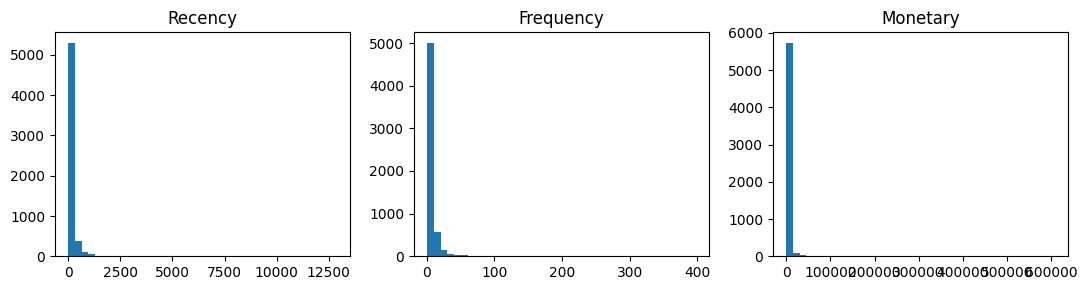

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = rfm[["recency","frequency","monetary"]].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init="auto", random_state=42)
rfm["cluster"] = kmeans.fit_predict(Xs)

# tiny summaries
display(rfm.groupby("cluster")[["recency","frequency","monetary"]].mean().round(2))

# histograms
fig, ax = plt.subplots(1,3, figsize=(11,3))
ax[0].hist(rfm["recency"], bins=40);   ax[0].set_title("Recency")
ax[1].hist(rfm["frequency"], bins=40); ax[1].set_title("Frequency")
ax[2].hist(rfm["monetary"], bins=40);  ax[2].set_title("Monetary")
plt.tight_layout(); plt.show()

In [7]:
rfm[["recency", "frequency", "monetary"]].describe().round(2)

,recency,frequency,monetary
count,5878.00,5878.00,5878.00
mean,137.04,6.29,3018.62
std,353.82,13.01,14737.73
min,1.00,1.00,2.95
25%,21.00,1.00,348.76
50%,53.00,3.00,898.92
75%,142.00,7.00,2307.09
max,12890.00,398.00,608821.65


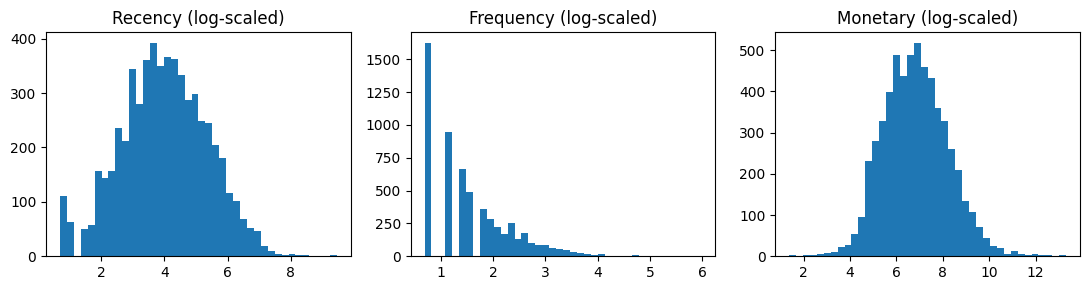

In [8]:
rfm_log = rfm.copy()
rfm_log[["recency", "frequency", "monetary"]] = np.log1p(rfm_log[["recency", "frequency", "monetary"]])

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].hist(rfm_log["recency"], bins=40)
ax[0].set_title("Recency (log-scaled)")

ax[1].hist(rfm_log["frequency"], bins=40)
ax[1].set_title("Frequency (log-scaled)")

ax[2].hist(rfm_log["monetary"], bins=40)
ax[2].set_title("Monetary (log-scaled)")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# Select and scale RFM metrics
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

print("Scaled shape:", rfm_scaled.shape)
print("Sample scaled data:\n", rfm_scaled[:5])

Scaled shape: (5878, 3)
Sample scaled data:
 [[-0.29126084  0.43899789  5.05805027]
 [ 0.32775301  0.13150188  0.17743068]
 [-0.24320953 -0.09912012 -0.06780567]
 [ 0.10728233 -0.17599412  0.09568591]
 [-0.33931214 -0.40661612 -0.18214779]]


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

elbow = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": silhouettes})
elbow

,k,inertia,silhouette
0,2,10214.516284,0.971027
1,3,7131.627594,0.802772
2,4,5439.106352,0.800019
3,5,4088.702239,0.760699
4,6,3347.163396,0.671713
5,7,2902.873632,0.672867
6,8,2545.537720,0.636675


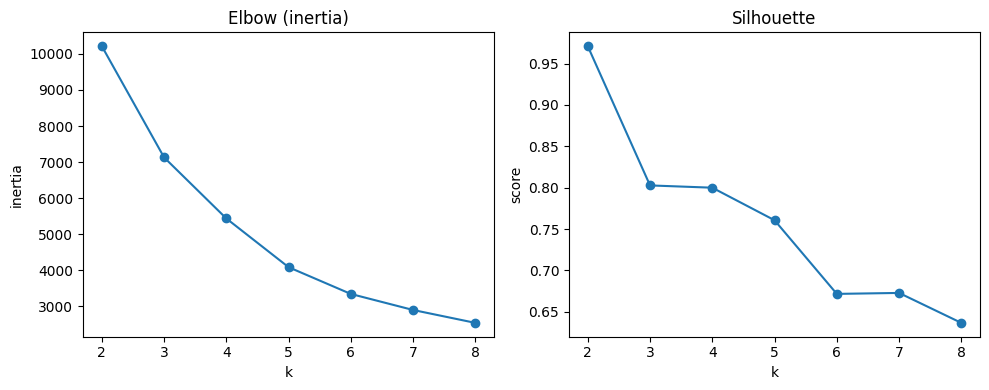

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(ks, inertias, marker='o'); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[1].plot(ks, silhouettes, marker='o'); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("score")
plt.tight_layout(); plt.show()

In [12]:
k_opt = 3  # ← change if your elbow/silhouette suggests another value
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
rfm["cluster"] = km.fit_predict(rfm_scaled)
rfm.head()

,customer_id,recency,frequency,monetary,cluster
0,12346.0,34,12,77556.46,1
1,12347.0,253,8,5633.32,0
2,12348.0,51,5,2019.40,0
3,12349.0,175,4,4428.69,0
4,12350.0,17,1,334.40,0


In [13]:
import plotly.express as px
fig = px.scatter_3d(
    rfm, x="recency", y="frequency", z="monetary",
    color="cluster", opacity=0.7,
    title=f"RFM Clusters (k={k_opt})"
)
fig.show()

In [14]:
profile = (
    rfm.groupby("cluster")[["recency","frequency","monetary"]]
       .mean().round(2)
       .sort_values("monetary", ascending=False)
)
counts = rfm["cluster"].value_counts().rename("customers")
summary = counts.to_frame().join(profile)
summary

,customers,recency,frequency,monetary
cluster,,,,
0,5520,89.09,4.28,1578.12
1,348,740.21,32.16,19242.82
2,10,5620.50,214.30,233567.95


In [15]:
from pathlib import Path
outputs = Path("./Outputs"); outputs.mkdir(exist_ok=True)
rfm.to_csv(outputs / "rfm_with_clusters.csv", index=False)
summary.to_csv(outputs / "cluster_summary.csv")
print("Saved to Outputs/")

Saved to Outputs/


In [16]:
# reuse the 'profile' table you already computed
# profile has mean recency, frequency, monetary by cluster
best   = profile.sort_values(
    ["monetary","frequency","recency"], ascending=[False, False, True]
).index[0]

worst  = profile.sort_values(
    ["recency","frequency","monetary"], ascending=[False, True, True]
).index[0]

mid = [c for c in profile.index if c not in [best, worst]][0]

labels = {
    best:  "VIP / High Value",
    mid:   "Loyal / Active Core",
    worst: "Dormant / At-risk"
}

rfm["segment"] = rfm["cluster"].map(labels)
rfm.head()

,customer_id,recency,frequency,monetary,cluster,segment
0,12346.0,34,12,77556.46,1,Loyal / Active Core
1,12347.0,253,8,5633.32,0,NaN
2,12348.0,51,5,2019.40,0,NaN
3,12349.0,175,4,4428.69,0,NaN
4,12350.0,17,1,334.40,0,NaN


In [17]:
seg_summary = (
    rfm.groupby("segment")
       .agg(customers=("cluster","size"),
            recency_med=("recency","median"),
            frequency_med=("frequency","median"),
            monetary_med=("monetary","median"))
       .sort_values("monetary_med", ascending=False)
)
seg_summary

,customers,recency_med,frequency_med,monetary_med
segment,,,,
Dormant / At-risk,10,4241.0,197.5,156626.985
Loyal / Active Core,348,651.5,27.0,11534.155


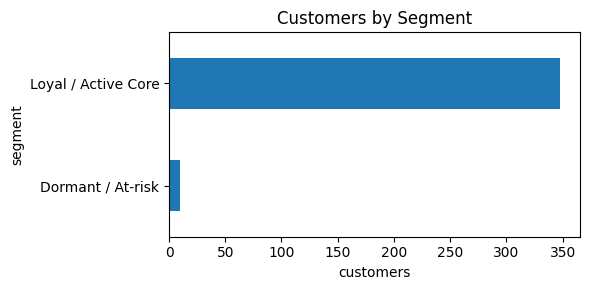

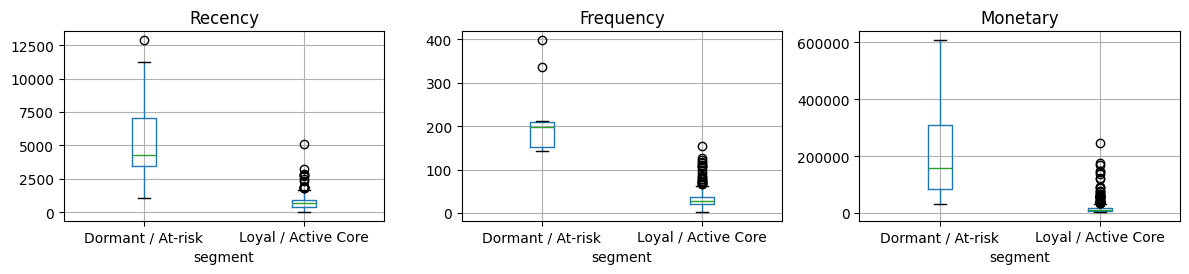

In [18]:
import matplotlib.pyplot as plt

# counts
ax = rfm["segment"].value_counts().sort_values().plot.barh(figsize=(6,3))
ax.set_title("Customers by Segment"); ax.set_xlabel("customers")
plt.tight_layout(); plt.show()

# boxplots per segment
fig, axes = plt.subplots(1,3, figsize=(12,3))
rfm.boxplot(column="recency", by="segment", ax=axes[0]); axes[0].set_title("Recency")
rfm.boxplot(column="frequency", by="segment", ax=axes[1]); axes[1].set_title("Frequency")
rfm.boxplot(column="monetary", by="segment", ax=axes[2]); axes[2].set_title("Monetary")
plt.suptitle(""); plt.tight_layout(); plt.show()

In [19]:
from pathlib import Path
out = Path("./Outputs"); out.mkdir(exist_ok=True)

rfm.to_csv(out / "rfm_with_clusters_and_segments.csv", index=False)
seg_summary.to_csv(out / "segment_summary.csv")
print("Saved: Outputs/rfm_with_clusters_and_segments.csv and segment_summary.csv")

Saved: Outputs/rfm_with_clusters_and_segments.csv and segment_summary.csv


In [20]:
rfm['cluster'].value_counts().sort_index()
rfm['segment'].value_counts()
profile  # the per-cluster means table you created earlier

,recency,frequency,monetary
cluster,,,
2,5620.50,214.30,233567.95
1,740.21,32.16,19242.82
0,89.09,4.28,1578.12


In [21]:
# Robust labeling (works even if clusters are close)
p = profile.copy()
# higher freq/monetary are good; lower recency is good
p['score'] = p['monetary'].rank(ascending=False) + \
             p['frequency'].rank(ascending=False) + \
             p['recency'].rank(ascending=True)

order = p.sort_values('score', ascending=False).index.tolist()  # best -> worst
labels = {
    order[0]: "VIP / High Value",
    order[1]: "Loyal / Active Core",
    order[2]: "Dormant / At-risk"
}
rfm['segment'] = rfm['cluster'].map(labels)
rfm['segment'].value_counts()

segment
VIP / High Value       5520
Loyal / Active Core     348
Dormant / At-risk        10
Name: count, dtype: int64

In [22]:
from pathlib import Path
out = Path("./Outputs"); out.mkdir(exist_ok=True)

rfm.query("segment == 'VIP / High Value'")[["customer_id","recency","frequency","monetary"]].to_csv(out/"targets_vip.csv", index=False)
rfm.query("segment == 'Loyal / Active Core'")[["customer_id","recency","frequency","monetary"]].to_csv(out/"targets_core.csv", index=False)
rfm.query("segment == 'Dormant / At-risk'")[["customer_id","recency","frequency","monetary"]].to_csv(out/"targets_atrisk.csv", index=False)
print("Saved VIP/Core/At-risk target lists to Outputs/")

Saved VIP/Core/At-risk target lists to Outputs/


In [23]:
import numpy as np

seg = rfm.groupby("segment").agg(
    orders=("frequency","median"),
    spend=("monetary","median"),
    recency_days=("recency","median")
).copy()

# crude frequency/month estimate
seg["freq_month"] = np.maximum(0.1, seg["orders"] / 12)
seg["aov"] = np.where(seg["orders"]>0, seg["spend"]/seg["orders"], 0)
margin, retention = 0.35, 0.60
seg["CLV_12m"] = seg["freq_month"]*12 * seg["aov"] * margin * retention
seg[["CLV_12m","freq_month","aov"]].round(2)

,CLV_12m,freq_month,aov
segment,,,
Dormant / At-risk,32891.67,16.46,793.05
Loyal / Active Core,2422.17,2.25,427.19
VIP / High Value,167.90,0.25,266.50
